# 02 — T15 real-data result
## Attempted vocalized speech vs passive listening with shared PCA

**Question.** When attempted speech and passive listening are placed in one common neural coordinate system, do their population trajectories and seven-word geometries differ?

This tracked, executed notebook is the exact T15 `i6v` threshold-crossing analysis shown in the README. Run `python3 scripts/reproduce.py` first to download and verify the released data; this notebook defaults to `configs/t15_interleaved_binnedtx.yaml`.

### What shared PCA means here

For the secondary trajectory view, one row is one `trial × time-bin` observation and one column is one neural feature. We fit a single pooled scaler and a single PCA on balanced observations from both conditions. PC1 is the weighted feature combination with the largest pooled variance; PC2 captures the next-largest orthogonal direction, and so on. Both conditions are projected through those exact same weights.

For the static word-geometry view, we average each trial in the predeclared analysis window, create 14 equally weighted `condition × word` centroids, and fit one second shared PCA for visualization. Quantitative geometry is computed in the full pooled-standardized channel space, not only in the first two or three PCs.

PCA is descriptive. Time bins are correlated and are never treated as independent replicates for inference.

In [1]:
from pathlib import Path
import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if not (ROOT / 'pyproject.toml').exists():
    raise RuntimeError('Run this notebook from the repository root or notebooks directory.')
sys.path.insert(0, str(ROOT / 'src'))

from kunz_speech_geometry.config import load_config
from kunz_speech_geometry.geometry import (
    centroid_distance,
    condition_subspace_angles_deg,
    stratified_permutation_test,
    time_resolved_centroid_distance,
    word_distance_matrices,
    word_geometry_scale_and_distortion,
    word_geometry_correlation,
)
from kunz_speech_geometry.io import load_interleaved_mat
from kunz_speech_geometry.pca import (
    fit_shared_pca,
    fit_word_centroid_pca,
    standardized_trial_vectors,
)
from kunz_speech_geometry.plotting import (
    plot_condition_trajectories,
    plot_permutation,
    plot_scree,
    plot_time_resolved_distance,
    plot_word_centroids,
    plot_word_rdms,
)
from kunz_speech_geometry.preprocess import smooth_and_baseline, window_mask
from kunz_speech_geometry.synthetic import make_synthetic_dataset

config_path = Path(
    os.environ.get(
        'KUNZ_CONFIG', ROOT / 'configs' / 't15_interleaved_binnedtx.yaml'
    )
)
if not config_path.is_absolute():
    config_path = ROOT / config_path
config = load_config(config_path)
seed = config['project']['random_seed']
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 12, 'axes.labelsize': 10})
config

{'project': {'random_seed': 20250821},
 'dataset': {'mode': 'mat',
  'variant': 'interleavedVerbalBehaviors',
  'mat_path': 'data/raw/interleavedVerbalBehaviors/t15.2024.06.14_interleavedVerbalBehaviors_raw.mat',
  'participant': 'T15',
  'feature': 'binnedTX',
  'units': 'counts/bin',
  'channel_sets': 'i6v',
  'epoch_ms': [-500, 1000],
  'block_center': True,
  'conditions': ['attempted_vocalized', 'passive_listening']},
 'preprocessing': {'alignment_event': 'condition-specific_behavior_onset',
  'baseline_window_ms': [-500, -100],
  'analysis_window_ms': [0, 500],
  'smoothing_sigma_ms': 60,
  'baseline_correct': True,
  'standardize_channels': True},
 'pca': {'n_components': 10,
  'balance_conditions_for_fit': True,
  'word_centroid_components': 3},
 'geometry': {'subspace_dimension': 3,
  'n_permutations': 500,
  'permutation_strata': ['session', 'block', 'word']},
 'outputs': {'save_figures': True,
  'figure_dir': 'results/figures/t15_interleaved_binnedtx',
  'table_dir': 'result

In [2]:
mode = config['dataset']['mode']
if mode == 'synthetic':
    dataset = make_synthetic_dataset(
        participant=config['dataset']['participant'],
        n_channels=config['synthetic']['n_channels'],
        n_trials_per_word_condition=config['synthetic']['n_trials_per_word_condition'],
        bin_width_ms=config['synthetic']['bin_width_ms'],
        random_state=seed,
    )
elif mode == 'mat':
    dataset = load_interleaved_mat(
        ROOT / config['dataset']['mat_path'],
        feature=config['dataset']['feature'],
        channel_sets=config['dataset'].get('channel_sets'),
        epoch_ms=tuple(config['dataset']['epoch_ms']),
        block_center=config['dataset'].get('block_center', True),
    )
else:
    raise ValueError(f'Unknown dataset.mode: {mode}')

dataset = dataset.subset_conditions(config['dataset']['conditions']).validate()
status = (
    f'MODE: {mode.upper()} — results below are pipeline validation only'
    if mode == 'synthetic'
    else f'MODE: MAT — {config_path.name}'
)
print(status)
print(f'rates shape [trial, time, channel]: {dataset.rates.shape}')
print(f'time: {dataset.time_ms[0]:.0f} to {dataset.time_ms[-1]:.0f} ms; bin = {dataset.bin_width_ms:.0f} ms')
print(f'feature: {dataset.feature_name} ({dataset.units}); aligned to {dataset.alignment_event}')

MODE: MAT — t15_interleaved_binnedtx.yaml
rates shape [trial, time, channel]: (308, 150, 64)
time: -500 to 990 ms; bin = 10 ms
feature: binnedTX_block_centered (counts/bin); aligned to condition-specific behavior onset


## 1. Data audit and balance

The analysis stops early if the canonical tensor or metadata are inconsistent. With real data, add QC for constant/bad channels, missing event windows, block order, and baseline drift before continuing.

In [3]:
trial_counts = (
    dataset.trials.groupby(['session', 'condition', 'word'])
    .size()
    .rename('n_trials')
    .reset_index()
)
display(trial_counts.pivot_table(index=['session', 'word'], columns='condition', values='n_trials', fill_value=0))

qc = pd.Series({
    'n_trials': dataset.rates.shape[0],
    'n_time_bins': dataset.rates.shape[1],
    'n_channels': dataset.rates.shape[2],
    'nan_or_inf_values': int((~np.isfinite(dataset.rates)).sum()),
    'constant_channels': int((dataset.rates.var(axis=(0, 1)) == 0).sum()),
    'n_sessions': dataset.trials['session'].nunique(),
    'n_words': dataset.trials['word'].nunique(),
})
display(qc.to_frame('value'))

condition              attempted_vocalized  passive_listening
session        word                                          
t15.2024.06.14 ban                    22.0               22.0
               choice                 22.0               22.0
               day                    22.0               22.0
               feel                   22.0               22.0
               kite                   22.0               22.0
               though                 22.0               22.0
               were                   22.0               22.0

,value
n_trials,308
n_time_bins,150
n_channels,64
nan_or_inf_values,0
constant_channels,0
n_sessions,1
n_words,7


## 2. Preprocessing and a secondary pooled trajectory PCA

Smoothing occurs within each already-epoched trial, so it cannot cross trial boundaries. Baseline subtraction is per trial and channel. The scaler and PCA are fitted once on the configured response window and balanced trial counts from both conditions, then applied to every time bin.

For the real data, confirm whether the published “60 ms Gaussian kernel” parameter denotes sigma or another width convention and add within-block drift sensitivity analyses.

In [4]:
pre = config['preprocessing']
processed = smooth_and_baseline(
    dataset,
    smoothing_sigma_ms=pre['smoothing_sigma_ms'],
    baseline_window_ms=pre['baseline_window_ms'],
    baseline_correct=pre['baseline_correct'],
)
analysis_mask = window_mask(processed.time_ms, pre['analysis_window_ms'])
labels = processed.trials['condition'].to_numpy()
shared = fit_shared_pca(
    processed.rates,
    labels,
    n_components=config['pca']['n_components'],
    fit_time_mask=analysis_mask,
    balance_conditions=config['pca']['balance_conditions_for_fit'],
    standardize_channels=pre['standardize_channels'],
    random_state=seed,
)
fit_counts = pd.Series(labels[shared.fit_trial_indices]).value_counts().rename('PCA fit trials')
display(fit_counts.to_frame())
print(f'Cumulative variance in {shared.scores.shape[2]} PCs: {shared.explained_variance_ratio.sum():.1%}')

,PCA fit trials
attempted_vocalized,154
passive_listening,154


Cumulative variance in 10 PCs: 33.4%


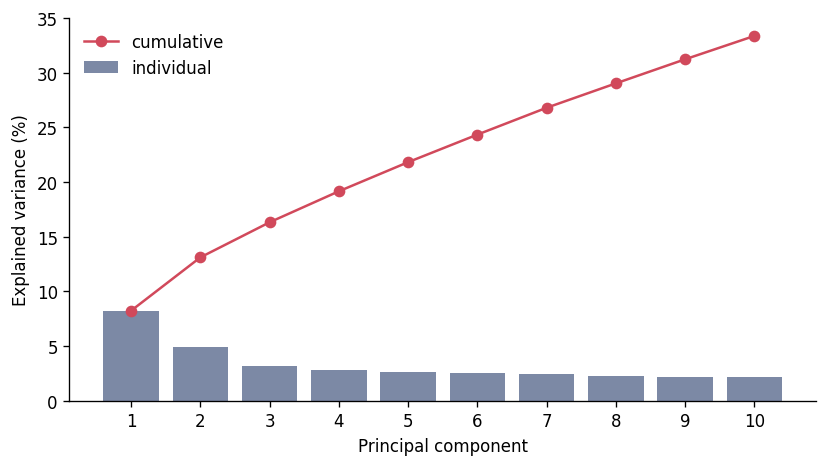

In [5]:
figure_dir = ROOT / config['outputs']['figure_dir']
table_dir = ROOT / config['outputs']['table_dir']
figure_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)

fig, _ = plot_scree(shared.explained_variance_ratio)
if config['outputs']['save_figures']:
    fig.savefig(figure_dir / f'{mode}_trajectory_pca_scree.png', bbox_inches='tight')
plt.show()

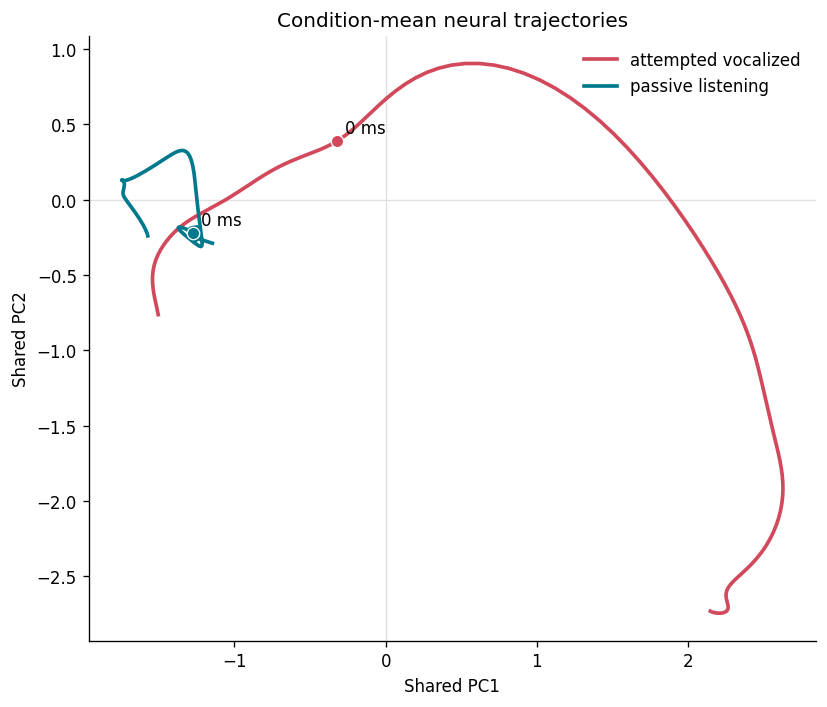

In [6]:
fig, _ = plot_condition_trajectories(shared.scores, labels, processed.time_ms)
if config['outputs']['save_figures']:
    fig.savefig(figure_dir / f'{mode}_condition_trajectories.png', bbox_inches='tight')
plt.show()

The trajectory is a condition mean through the shared PC space. Its path is useful for timing hypotheses, but adjacent bins are correlated and do not increase the inferential sample size. A large PC1 separation may be a global-gain difference rather than changed word geometry.

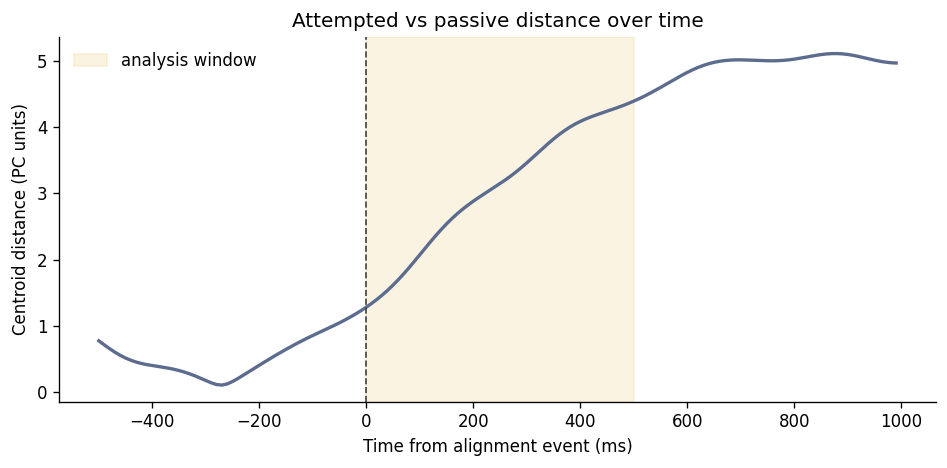

In [7]:
distance_over_time = time_resolved_centroid_distance(shared.scores, labels)
fig, _ = plot_time_resolved_distance(processed.time_ms, distance_over_time, pre['analysis_window_ms'])
if config['outputs']['save_figures']:
    fig.savefig(figure_dir / f'{mode}_time_resolved_distance.png', bbox_inches='tight')
plt.show()

## 3. Primary static word geometry in full feature space

Each trial is averaged over the fixed analysis window and transformed with the same pooled feature scaler used above. Geometry statistics use all standardized features. The 14 condition-by-word centroids receive equal weight in a separate shared PCA used only for the figure. Connecting lines show matched word identity; they are not statistical edges. RDM panels use the same distance color scale across conditions.

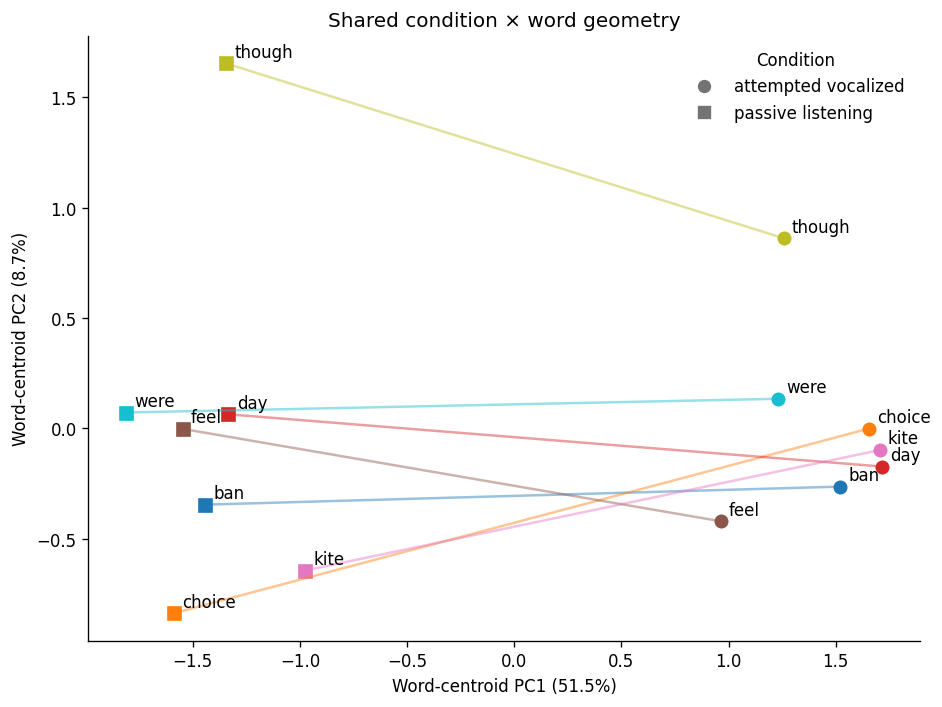

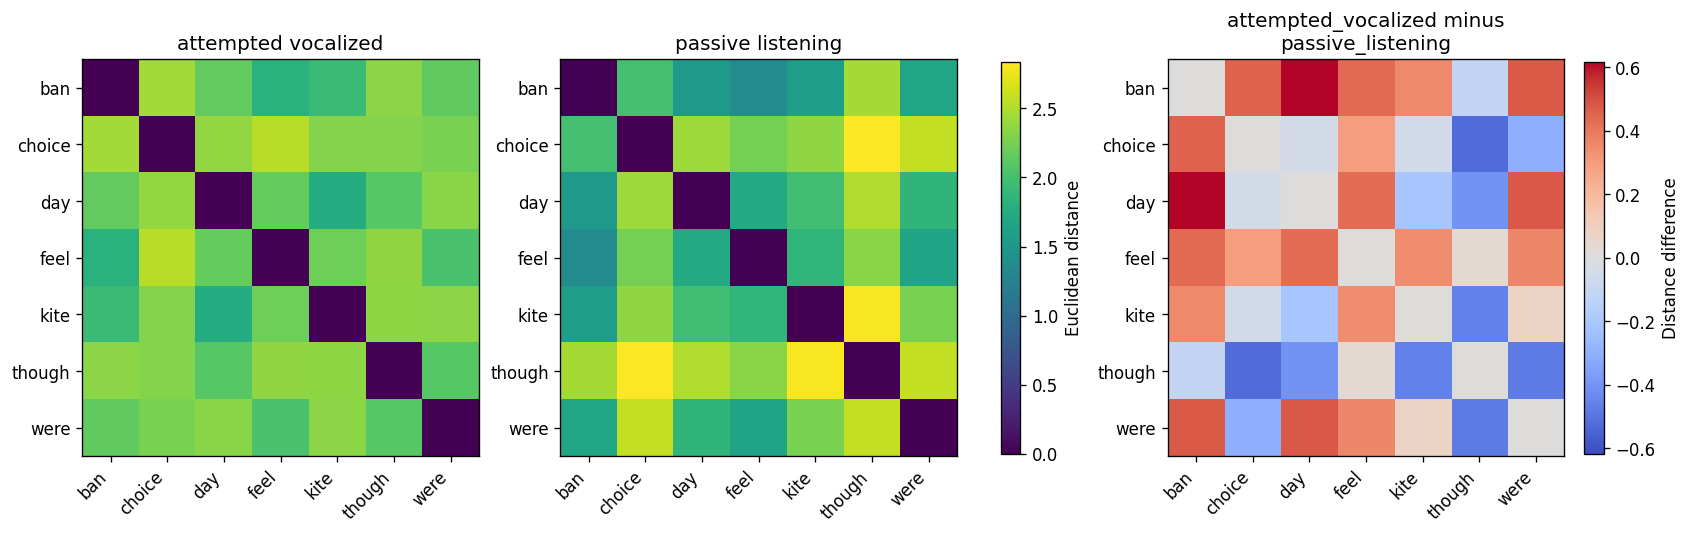

In [8]:
full_vectors = standardized_trial_vectors(processed.rates, analysis_mask, shared)
word_pca = fit_word_centroid_pca(
    full_vectors,
    processed.trials,
    n_components=config['pca']['word_centroid_components'],
)
fig, _ = plot_word_centroids(word_pca)
if config['outputs']['save_figures']:
    fig.savefig(figure_dir / f'{mode}_word_centroid_geometry.png', bbox_inches='tight')
plt.show()

rdm_conditions, rdm_words, rdms = word_distance_matrices(full_vectors, processed.trials)
fig, _ = plot_word_rdms(rdm_conditions, rdm_words, rdms)
if config['outputs']['save_figures']:
    fig.savefig(figure_dir / f'{mode}_word_rdms.png', bbox_inches='tight')
plt.show()

In [9]:
rho, rho_p, shared_words = word_geometry_correlation(full_vectors, processed.trials)
word_spread, centered_distortion = word_geometry_scale_and_distortion(
    full_vectors, processed.trials
)
global_distance = centroid_distance(full_vectors, labels)
angles = condition_subspace_angles_deg(
    shared.scores,
    labels,
    analysis_mask,
    subspace_dimension=config['geometry']['subspace_dimension'],
)
geometry_summary = pd.Series({
    'full-space condition centroid distance': global_distance,
    'word-RDM Spearman rho': rho,
    'naive Spearman p (descriptive only)': rho_p,
    'condition-centered word distortion': centered_distortion,
    **{f'word spread — {condition}': value for condition, value in word_spread.items()},
    'smallest subspace angle (degrees)': float(angles.min()),
    'largest subspace angle (degrees)': float(angles.max()),
})
display(geometry_summary.to_frame('value'))
print('Shared words:', ', '.join(shared_words))
print('Principal angles (degrees):', np.round(angles, 2))

,value
full-space condition centroid distance,2.873072
word-RDM Spearman rho,0.432468
naive Spearman p (descriptive only),0.050230
condition-centered word distortion,1.909861
word spread — attempted_vocalized,2.208063
word spread — passive_listening,2.124087
smallest subspace angle (degrees),63.518083
largest subspace angle (degrees),84.625352


Shared words: ban, choice, day, feel, kite, though, were
Principal angles (degrees): [84.63 76.34 63.52]


Interpretation: centroid distance measures an overall condition shift; word-RDM correlation asks whether pairwise word relationships are preserved; principal angles compare dominant variance orientations. None identifies a uniquely motor-intent signal in an attempted-versus-listening contrast, because production, perception, audio input, preparation, and timing all differ.

## 4. Whole-trial stratified permutation

Condition labels are shuffled only within `session × block × word` strata. The statistic is recomputed on trial response vectors, so time bins and channels are not treated as replicates. In properly interleaved files, each stratum can contain both conditions. In isolated files, condition is tied to block; the test must refuse or be treated as scientifically invalid rather than manufacturing exchangeability across blocks.

Observed distance: 2.873
Permutation p-value: 0.0020
Exchangeable strata: 35


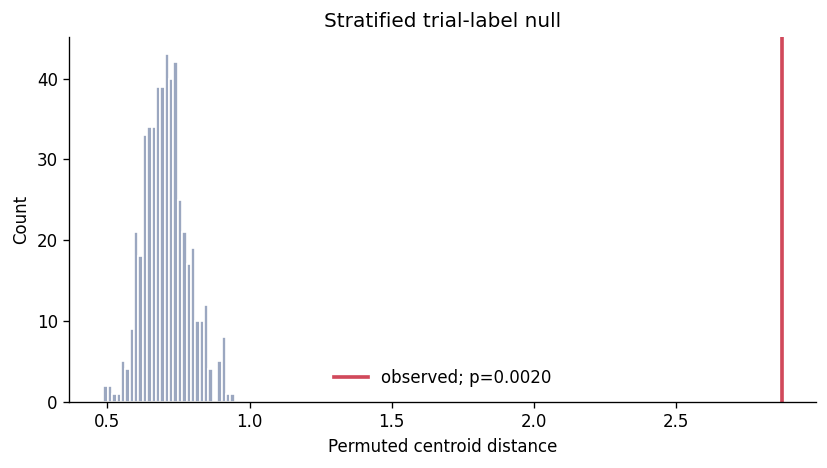

In [10]:
permutation = stratified_permutation_test(
    full_vectors,
    processed.trials,
    strata_columns=config['geometry']['permutation_strata'],
    n_permutations=config['geometry']['n_permutations'],
    random_state=seed,
)
print(f'Observed distance: {permutation.observed:.3f}')
print(f'Permutation p-value: {permutation.p_value:.4f}')
print(f'Exchangeable strata: {permutation.exchangeable_strata}')
fig, _ = plot_permutation(
    permutation.null_distribution, permutation.observed, permutation.p_value
)
if config['outputs']['save_figures']:
    fig.savefig(figure_dir / f'{mode}_centroid_permutation.png', bbox_inches='tight')
plt.show()

## 5. Sensitivity to retained trajectory PCs

The full-channel statistic above is primary. This curve checks whether a visual claim based on only two or three PCs would omit much of the condition distance.

,n_pcs,centroid_distance,cumulative_variance
0,1,2.610941,0.082276
1,2,2.612358,0.131058
2,3,2.735807,0.163157
3,4,2.792278,0.191522
4,5,2.792529,0.218146
5,6,2.792544,0.243344
6,7,2.795034,0.267910
7,8,2.804123,0.290223
8,9,2.804144,0.312248
9,10,2.811895,0.333600


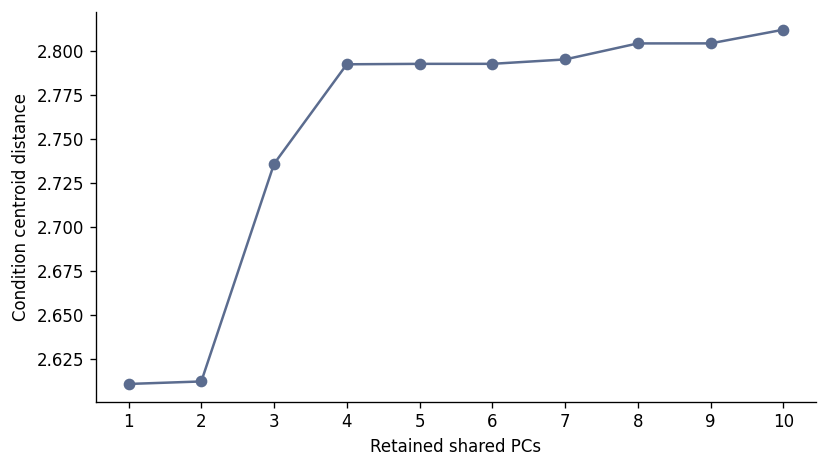

In [11]:
pc_sensitivity = []
for n_pcs in range(1, shared.scores.shape[2] + 1):
    vectors_k = shared.scores[:, analysis_mask, :n_pcs].mean(axis=1)
    pc_sensitivity.append({
        'n_pcs': n_pcs,
        'centroid_distance': centroid_distance(vectors_k, labels),
        'cumulative_variance': shared.explained_variance_ratio[:n_pcs].sum(),
    })
pc_sensitivity = pd.DataFrame(pc_sensitivity)
display(pc_sensitivity)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(pc_sensitivity['n_pcs'], pc_sensitivity['centroid_distance'], 'o-', color='#5B6C8F')
ax.set(xlabel='Retained shared PCs', ylabel='Condition centroid distance', xticks=pc_sensitivity['n_pcs'])
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

In [12]:
summary = {
    'data_mode': mode,
    'participant': str(processed.trials['participant'].iloc[0]),
    'n_trials': int(processed.rates.shape[0]),
    'n_channels': int(processed.rates.shape[2]),
    'analysis_window_ms': list(pre['analysis_window_ms']),
    'centroid_distance_full_space': float(global_distance),
    'word_rdm_spearman_rho': float(rho),
    'condition_centered_word_distortion': float(centered_distortion),
    'word_spread': {key: float(value) for key, value in word_spread.items()},
    'permutation_p_value': float(permutation.p_value),
    'random_seed': int(seed),
    'warning': 'Synthetic demonstration; not a scientific result.' if mode == 'synthetic' else (
        f"Dataset variant: {config['dataset']['variant']}; verify block-level exchangeability."
    ),
}
with (table_dir / f'{mode}_analysis_summary.json').open('w', encoding='utf-8') as handle:
    json.dump(summary, handle, indent=2)
pc_sensitivity.to_csv(table_dir / f'{mode}_pc_sensitivity.csv', index=False)
summary

{'data_mode': 'mat',
 'participant': 'T15',
 'n_trials': 308,
 'n_channels': 64,
 'analysis_window_ms': [0, 500],
 'centroid_distance_full_space': 2.8730715664666975,
 'word_rdm_spearman_rho': 0.4324675324675325,
 'condition_centered_word_distortion': 1.909860741843529,
 'word_spread': {'attempted_vocalized': 2.2080633840568384,
  'passive_listening': 2.1240871398008587},
 'permutation_p_value': 0.001996007984031936,
 'random_seed': 20250821,
 'warning': 'Dataset variant: interleavedVerbalBehaviors; verify block-level exchangeability.'}

## Next decisions after real-data audit

1. Select one participant, session, array, and feature type before viewing condition separation.
2. Verify event semantics separately for attempted speech and audio onset.
3. Use the interleaved task for the direct contrast; reserve isolated blocks for descriptive analyses.
4. Add leave-one-session/block/word-out checks and cross-validated distances.
5. Reproduce paper-style 500 ms word vectors with documented windows.
6. For T16, retain the label `attempted_mimed`; do not merge it with vocalized attempted speech.
7. Analyze threshold crossings and spike-band power separately before considering concatenation.